### **Expanding**
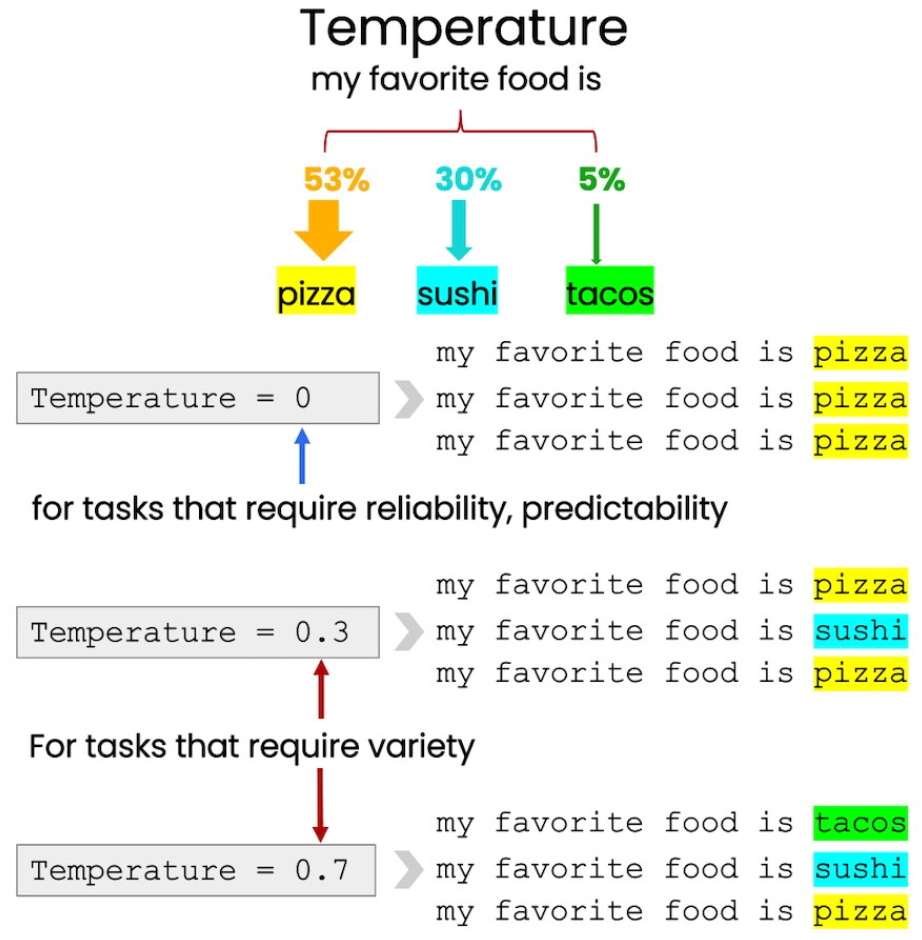
#### **Setup**

In [1]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI
from pprint import pprint


_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-3.5-turbo'
chat = ChatOpenAI(model = llm_model, temperature = 0)

#### **Customize the automated reply to a customer email**

In [ ]:
# given the sentiment from the lesson on 'inferring',
# and the original customer message, customize the email
sentiment = 'negative'

# review for a blender
review = f'''
So, they still had the 17 piece system on seasonal \
sale for around $49 in the month of November, about \
half off, but for some reason (call it price gouging) \
around the second week of December the prices all went \
up to about anywhere from between $70-$89 for the same \
system. And the 11 piece system went up around $10 or \
so in price also from the earlier sale price of $29. \
So it looks okay, but if you look at the base, the part \
where the blade locks into place doesn’t look as good \
as in previous editions from a few years ago, but I \
plan to be very gentle with it (example, I crush \
very hard items like beans, ice, rice, etc. in the \
blender first then pulverize them in the serving size \
I want in the blender then switch to the whipping \
blade for a finer flour, and use the cross cutting blade \
first when making smoothies, then use the flat blade \
if I need them finer/less pulpy). Special tip when making \
smoothies, finely cut and freeze the fruits and \
vegetables (if using spinach-lightly stew soften the \
spinach then freeze until ready for use-and if making \
sorbet, use a small to medium sized food processor) \
that you plan to use that way you can avoid adding so \
much ice if at all-when making your smoothie. \
After about a year, the motor was making a funny noise. \
I called customer service but the warranty expired \
already, so I had to buy another one. FYI: The overall \
quality has gone done in these types of products, so \
they are kind of counting on brand recognition and \
consumer loyalty to maintain sales. Got it in about \
two days.
'''

prompt = f'''
You are a customer service AI assistant.
Your task is to send an email reply to a valued customer.
Given the customer email delimited by ```, \
Generate a reply to thank the customer for their review.
If the sentiment is positive or neutral, thank them for \
their review.
If the sentiment is negative, apologize and suggest that \
they can reach out to customer service. 
Make sure to use specific details from the review.
Write in a concise and professional tone.
Sign the email as `AI customer agent`.
Customer review: ```{review}```
Review sentiment: {sentiment}
'''

response = chat.invoke(prompt)
pprint(response.content)

('Dear valued customer,\n'
 '\n'
 'Thank you for taking the time to share your detailed feedback with us. We '
 'are sorry to hear about the issues you experienced with the pricing changes '
 'and the quality of the product. We apologize for any inconvenience this may '
 'have caused you.\n'
 '\n'
 'If you have any further concerns or would like to discuss this matter '
 'further, please feel free to reach out to our customer service team. They '
 'will be more than happy to assist you.\n'
 '\n'
 'We appreciate your loyalty and feedback as it helps us improve our products '
 'and services for all our customers.\n'
 '\n'
 'Thank you again for your review.\n'
 '\n'
 'AI customer agent')


#### **Remind the model to use details from the customer's email**

In [3]:
response = chat.invoke(prompt, temperature=0.9)
pprint(response.content)

('Subject: Thank you for your feedback\n'
 '\n'
 'Dear valued customer,\n'
 '\n'
 'Thank you for taking the time to share your insightful feedback with us '
 'regarding your recent purchase of the blender system. We sincerely apologize '
 'for any inconvenience you experienced with the pricing fluctuations and '
 'quality concerns you mentioned in your review.\n'
 '\n'
 'We strive to provide our customers with high-quality products and '
 'exceptional service, and it is disappointing to hear that your experience '
 'did not meet your expectations. If you have any further issues or concerns, '
 'please do not hesitate to reach out to our customer service team for '
 'assistance.\n'
 '\n'
 'We appreciate your feedback as it helps us identify areas for improvement '
 'and ensure a better experience for all our customers in the future.\n'
 '\n'
 'Thank you for being a loyal customer and for sharing your experience with '
 'us.\n'
 '\n'
 'AI customer agent')
